# uxarray-mcp without an AI client

This notebook drives the exact same tools that an MCP/AI client would call,
but **directly from Python** — no Claude, no LLM, no MCP transport.

Three layers are shown, simplest first:

1. **Plain function imports** — `from uxarray_mcp.tools import inspect_mesh`.
   The tools are ordinary Python functions returning JSON-able dicts.
2. **Registry `get_callable`** — call tools *by name* through the same
   `make_registry()` object the MCP server uses. This is the bridge for
   REST/OpenAPI or any non-AI dispatcher.
3. **Plotting** — tools return base64-encoded PNGs; we decode and display
   them inline (and the same bytes go over REST).

No sample data ships with the repo, so we first synthesize a small UGRID
mesh + a data variable on disk.

In [1]:
import base64
import json
import os
import tempfile

import xarray as xr

print("Building a synthetic UGRID mesh + data file...")
work = tempfile.mkdtemp(prefix="uxmcp_demo_")
grid_path = os.path.join(work, "grid.nc")
data_path = os.path.join(work, "data.nc")

# Two quad faces over a 6-node lon/lat patch (CF UGRID conventions).
grid = xr.Dataset(
    {
        "Mesh2": (
            [],
            0,
            {
                "cf_role": "mesh_topology",
                "topology_dimension": 2,
                "node_coordinates": "Mesh2_node_x Mesh2_node_y",
                "face_node_connectivity": "Mesh2_face_nodes",
            },
        ),
        "Mesh2_node_x": (["nMesh2_node"], [0.0, 10.0, 20.0, 0.0, 10.0, 20.0]),
        "Mesh2_node_y": (["nMesh2_node"], [0.0, 0.0, 0.0, 10.0, 10.0, 10.0]),
        "Mesh2_face_nodes": (
            ["nMesh2_face", "nMaxMesh2_face_nodes"],
            [[0, 1, 4, 3], [1, 2, 5, 4]],
            {"cf_role": "face_node_connectivity", "start_index": 0},
        ),
    }
)
grid.to_netcdf(grid_path)

data = xr.Dataset(
    {
        "temperature": (
            ["nMesh2_face"],
            [280.0, 295.0],
            {"units": "K", "long_name": "air_temperature"},
        )
    }
)
data.to_netcdf(data_path)

print("grid_path:", grid_path)
print("data_path:", data_path)

Building a synthetic UGRID mesh + data file...
grid_path: /var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc
data_path: /var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/data.nc


## Layer 1 — call tools as plain Python functions

Every tool returns a JSON-serializable dict (plus a `_provenance` block).
This is all you need for scripts, pipelines, or a Fortran/C post-processor
that shells out to a Python helper.

In [2]:
from uxarray_mcp.tools import calculate_area, inspect_mesh, inspect_variable


def show(title, result):
    """Pretty-print a tool result, hiding the verbose provenance block."""
    print(f"=== {title} ===")
    clean = {k: v for k, v in result.items() if k != "_provenance"}
    print(json.dumps(clean, indent=2, default=str))
    print()


show("inspect_mesh", inspect_mesh(file_path=grid_path))
show("calculate_area", calculate_area(file_path=grid_path))
show(
    "inspect_variable",
    inspect_variable(
        grid_path=grid_path, data_path=data_path, variable_name="temperature"
    ),
)

=== inspect_mesh ===
{
  "format": "UGRID",
  "n_face": 2,
  "n_node": 6,
  "n_edge": 7,
  "n_max_face_nodes": 4,
  "file_size_mb": 0.01,
  "recommended_next_steps": [
    "calculate_area(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "inspect_variable(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\")",
    "validate_dataset(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\")"
  ]
}

=== calculate_area ===
{
  "total_area": 0.06076431606044129,
  "mean_area": 0.030382158030220645,
  "min_area": 0.030382158030220638,
  "max_area": 0.03038215803022065,
  "area_units": "m^2",
  "n_face": 2,
  "recommended_next_steps": [
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "inspect_variable(\"/var/folders/_f/

### Provenance is always attached

Every result carries a `_provenance` record — where it ran, tool version,
inputs. This is what makes results reproducible and auditable, independent
of any AI client.

In [3]:
prov = inspect_mesh(file_path=grid_path)["_provenance"]
print(json.dumps(prov, indent=2, default=str))

{
  "tool": "inspect_mesh",
  "inputs": {
    "file_path": "/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc"
  },
  "execution_venue": "local",
  "timestamp_utc": "2026-06-24T14:38:08.700962+00:00",
  "uxarray_version": "2026.6.0",
  "python_version": "3.12.10",
  "warnings": [],
  "artifacts": [],
  "operation_id": "op_b7036178f937"
}


## Layer 2 — call tools *by name* through the registry

`make_registry()` returns the very same `ToolRegistry` the MCP server wires
up. `get_callable(name)` hands you the function for any registered tool, so
a REST/OpenAPI front end (or your own dispatcher) can route
`{"tool": "...", "args": {...}}` requests with no AI in the loop.

In [4]:
from uxarray_mcp.app import make_registry

reg = make_registry(profile="core")
tools = reg.list_tools()
print(f"core profile exposes {len(tools)} tools:\n")
for t in sorted(tools):
    print(" ", t)

core profile exposes 31 tools:

  analyze_dataset
  diagnose_endpoint
  get_capabilities
  get_result
  get_status
  hpc-endpoint_status
  hpc-get_execution_mode
  hpc-set_execution_mode
  hpc-validate_hpc_setup
  io-list_datasets
  manage_session
  plot_dataset
  probe_path_access
  prompt-climatology_anomaly
  prompt-cyclone_structure
  prompt-eddy_activity
  prompt-first_look
  prompt-hpc_diagnose
  prompt-model_evaluation
  prompt-vorticity_analysis
  resume_workflow
  run_analysis
  run_workflow
  session-create_session
  session-get_operation_status
  session-get_result_handle
  session-get_session_state
  session-get_workflow_status
  session-list_operations
  session-register_dataset
  session-reset_session_state


The front-door `run_analysis` dispatcher takes an `operation` string and
routes to the right computation — this is the single entry point a thin
REST handler would expose.

In [5]:
run_analysis = reg.get_callable("run_analysis")

for op in ("inspect_mesh", "calculate_area"):
    res = run_analysis(operation=op, grid_path=grid_path)
    show(f"run_analysis(operation={op!r})", res)

# zonal mean needs a variable
res = run_analysis(
    operation="inspect_variable",
    grid_path=grid_path,
    data_path=data_path,
    variable_name="temperature",
)
show("run_analysis(operation='inspect_variable')", res)

=== run_analysis(operation='inspect_mesh') ===
{
  "format": "UGRID",
  "n_face": 2,
  "n_node": 6,
  "n_edge": 7,
  "n_max_face_nodes": 4,
  "file_size_mb": 0.01,
  "recommended_next_steps": [
    "calculate_area(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "inspect_variable(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\")",
    "validate_dataset(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\")"
  ]
}

=== run_analysis(operation='calculate_area') ===
{
  "total_area": 0.06076431606044129,
  "mean_area": 0.030382158030220645,
  "min_area": 0.030382158030220638,
  "max_area": 0.03038215803022065,
  "area_units": "m^2",
  "n_face": 2,
  "recommended_next_steps": [
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/g

### Simulating a REST request without a server

A REST handler receives JSON, looks up the tool, and calls it. Here is that
exact flow in three lines — swap `incoming` for an HTTP body and you have
the OpenAPI surface, no AI client required.

In [6]:
incoming = {
    "tool": "run_analysis",
    "args": {"operation": "calculate_area", "grid_path": grid_path},
}

fn = reg.get_callable(incoming["tool"])
response = fn(**incoming["args"])
print(
    json.dumps(
        {k: v for k, v in response.items() if k != "_provenance"}, indent=2, default=str
    )
)

{
  "total_area": 0.06076431606044129,
  "mean_area": 0.030382158030220645,
  "min_area": 0.030382158030220638,
  "max_area": 0.03038215803022065,
  "area_units": "m^2",
  "n_face": 2,
  "recommended_next_steps": [
    "plot_mesh(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\")",
    "inspect_variable(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\")",
    "calculate_zonal_mean(\"/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc\", \"<data_path>\", \"<variable_name>\")"
  ]
}


## Layer 3 — plots come back as base64 PNGs

Plotting tools return a list of MCP content objects; the image is a
base64-encoded PNG string in `items[0].data`. No file is written to disk —
the same bytes travel over REST/MCP. We decode and display it inline.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

returned: ['ImageContent', 'TextContent']
decoded PNG size: 8936 bytes
wrote: /var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/mesh.png


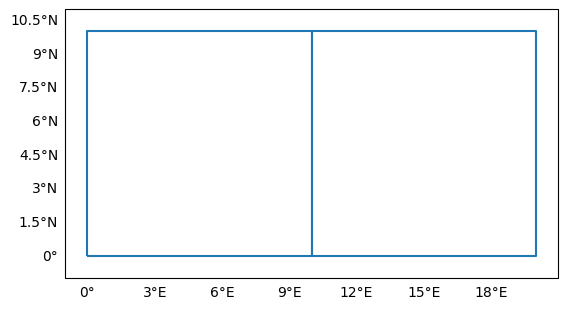

In [7]:
from IPython.display import Image, display

from uxarray_mcp.tools import plot_mesh

items = plot_mesh(grid_path, width=640, height=320)
print("returned:", [type(i).__name__ for i in items])

png_bytes = base64.b64decode(items[0].data)
print("decoded PNG size:", len(png_bytes), "bytes")

# Save a copy and show it
out_png = os.path.join(work, "mesh.png")
with open(out_png, "wb") as fh:
    fh.write(png_bytes)
print("wrote:", out_png)

display(Image(data=png_bytes))

### The text item carries provenance

The second content item is the provenance JSON, so even an image response
is fully traceable.

In [8]:
print(items[1].text)

{
  "image_size_bytes": 8936,
  "grid_info": {
    "n_face": 2,
    "n_node": 6,
    "n_edge": 7
  },
  "execution_venue": "local",
  "_provenance": {
    "tool": "plot_mesh",
    "inputs": {
      "grid_path": "/var/folders/_f/dc3kjt3n3ms9ntb5fcj5mplm0000gq/T/uxmcp_demo_6rb8pafj/grid.nc",
      "width": 640,
      "height": 320,
      "session_id": null,
      "dataset_handle": null
    },
    "execution_venue": "local",
    "timestamp_utc": "2026-06-24T14:38:12.854490+00:00",
    "uxarray_version": "2026.6.0",
    "python_version": "3.12.10",
    "warnings": [],
    "artifacts": [
      {
        "type": "plot",
        "plot_type": "mesh_wireframe",
        "format": "png",
        "size_bytes": 8936
      }
    ],
    "operation_id": "op_f58bdee9c2b6"
  }
}


## No file at all: HEALPix pseudo-path

For mesh-only tools you can pass `"healpix:<zoom>"` instead of a file path
and a HEALPix grid is generated on the fly — handy for quick checks with no
data on disk.

In [9]:
show("inspect_mesh on healpix:2", inspect_mesh(file_path="healpix:2"))

=== inspect_mesh on healpix:2 ===
{
  "format": "HEALPix",
  "n_face": 192,
  "n_node": 194,
  "n_edge": 384,
  "n_max_face_nodes": 4,
  "file_size_mb": 0.0
}



## Summary

| Need | No-AI-client call |
|---|---|
| One specific computation | `from uxarray_mcp.tools import inspect_mesh; inspect_mesh(...)` |
| Call by name / build a REST router | `reg = make_registry(); reg.get_callable(name)(**args)` |
| List available tools | `reg.list_tools()` |
| Plots | tool returns base64 PNG -> `base64.b64decode(items[0].data)` |
| Reproducibility | every result has `_provenance` |

The MCP server and any AI client call these *same* functions. Dropping the
AI client changes nothing about the computation, the results, or provenance.